# Feature Engineering (Distributed Spark)

This notebook builds a dense 10-minute demand table by ZoneID and creates time-series features.

Outputs:
- HDFS: /user/data/feature_engineering/demand_prediction_dense_10m
- HDFS: /user/data/feature_engineering/demand_prediction_features
- Local artifacts: /workspace/code/hybrid_regression_holt_winters/artifacts/feature_engineering
- Local results: /workspace/code/hybrid_regression_holt_winters/results/feature_engineering

Time window behavior:
- Auto-detects available min/max timestamp from input data by default.
- Optionally set START_TS and END_TS to limit the window.

In [1]:
import json
import os
import urllib.request

import matplotlib.pyplot as plt
import pandas as pd
from pyspark.sql import SparkSession, functions as F, Window

spark = (
    SparkSession.builder
    .appName("DemandPredictionFeatureEngineering")
    .master("spark://master:7077")
    .config("spark.driver.memory", "2g")
    .config("spark.executor.memory", "2g")
    .config("spark.eventLog.enabled", "true")
    .config("spark.eventLog.dir", "hdfs://master:9000/spark-logs")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

def cluster_util(stage_name):
    print(f"\n===== CLUSTER UTILIZATION: {stage_name} =====")
    print("Spark master:", spark.sparkContext.master)
    try:
        payload = json.load(urllib.request.urlopen("http://master:8080/json/"))
        workers = payload.get("workers", [])
        print("alive workers:", payload.get("aliveworkers"))
        print("active apps :", len(payload.get("activeapps", [])))
        for w in workers:
            print("worker", w.get("id"), "cores", f"{w.get('coresused', 0)}/{w.get('cores', 0)}", "memory", f"{w.get('memoryused', 0)}/{w.get('memory', 0)}")
    except Exception as e:
        print("Could not query Spark Master JSON:", e)

cluster_util("session_started")

:: loading settings :: url = jar:file:/opt/spark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /root/.ivy2/cache
The jars for the packages stored in: /root/.ivy2/jars
graphframes#graphframes added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-b76ae4df-ca87-49cf-a8e0-e6449eb40e42;1.0
	confs: [default]
	found graphframes#graphframes;0.8.3-spark3.5-s_2.12 in spark-packages
	found org.slf4j#slf4j-api;1.7.16 in central
downloading https://repos.spark-packages.org/graphframes/graphframes/0.8.3-spark3.5-s_2.12/graphframes-0.8.3-spark3.5-s_2.12.jar ...
	[SUCCESSFUL ] graphframes#graphframes;0.8.3-spark3.5-s_2.12!graphframes.jar (705ms)
downloading https://repo1.maven.org/maven2/org/slf4j/slf4j-api/1.7.16/slf4j-api-1.7.16.jar ...
	[SUCCESSFUL ] org.slf4j#slf4j-api;1.7.16!slf4j-api.jar (96ms)
:: resolution report :: resolve 2216ms :: artifacts dl 807ms
	:: modules in use:
	graphframes#graphframes;0.8.3-spark3.5-s_2.12 from spark-packages in [default]
	org.slf4j#slf4j-api;1.7.16 from central in [default]
	-----------------------


===== CLUSTER UTILIZATION: session_started =====
Spark master: spark://master:7077
alive workers: 3
active apps : 1
worker worker-20260404034934-172.18.0.3-7078 cores 2/2 memory 2048/2048
worker worker-20260404034934-172.18.0.4-7078 cores 2/2 memory 2048/2048
worker worker-20260404035026-172.18.0.2-7078 cores 0/1 memory 0/1024


In [4]:
RAW_PATH = "/user/data/raw/*.parquet"
OUT_DENSE = "/user/data/feature_engineering/demand_prediction_dense_10m"
OUT_FEATURES = "/user/data/feature_engineering/demand_prediction_features"

LOCAL_BASE = "/workspace/code/hybrid_regression_holt_winters"
LOCAL_RESULTS_DIR = f"{LOCAL_BASE}/results/feature_engineering"
LOCAL_ARTIFACTS_DIR = f"{LOCAL_BASE}/artifacts/feature_engineering"
os.makedirs(LOCAL_RESULTS_DIR, exist_ok=True)
os.makedirs(LOCAL_ARTIFACTS_DIR, exist_ok=True)

# Optional manual override; keep None to auto-detect from data.
START_TS = None
END_TS = None

ZONE_COL = "PULocationID"
BIN_COL = "pickup_bin_10m"
TARGET_COL = "pickup_demand"

raw_df = spark.read.parquet(RAW_PATH)
pickup_col_candidates = ["tpep_pickup_datetime", "lpep_pickup_datetime", "pickup_datetime"]
pickup_col = next((c for c in pickup_col_candidates if c in raw_df.columns), None)

if pickup_col is None:
    raise ValueError(f"Cannot find pickup timestamp column. Tried: {pickup_col_candidates}")
if ZONE_COL not in raw_df.columns:
    raise ValueError(f"Missing column: {ZONE_COL}")

base_trips = (
    raw_df
    .select(
        F.to_timestamp(F.col(pickup_col)).alias("pickup_ts"),
        F.col(ZONE_COL).cast("int").alias(ZONE_COL)
    )
    .where(F.col("pickup_ts").isNotNull() & F.col(ZONE_COL).isNotNull())
    .where(F.col(ZONE_COL) > 0)
)

available_bounds = base_trips.agg(
    F.min("pickup_ts").alias("min_ts"),
    F.max("pickup_ts").alias("max_ts")
).first()

if available_bounds["min_ts"] is None or available_bounds["max_ts"] is None:
    raise ValueError(
        "No valid rows found after parsing pickup timestamp and ZoneID. "
        "Check RAW_PATH, timestamp format, and zone column values."
    )

effective_start = START_TS if START_TS is not None else available_bounds["min_ts"]
effective_end = END_TS if END_TS is not None else available_bounds["max_ts"]

window_cond = F.col("pickup_ts") >= F.lit(effective_start)
if END_TS is not None:
    window_cond = window_cond & (F.col("pickup_ts") < F.lit(effective_end))
else:
    window_cond = window_cond & (F.col("pickup_ts") <= F.lit(effective_end))

trips = base_trips.where(window_cond)
trip_rows = trips.count()
if trip_rows == 0:
    raise ValueError(
        f"No rows in requested period [{effective_start}, {effective_end}]. "
        f"Available data range is [{available_bounds['min_ts']}, {available_bounds['max_ts']}]."
    )

print("Using pickup column:", pickup_col)
print("Effective window:", effective_start, "->", effective_end)
print("Trips used:", trip_rows)
cluster_util("after_raw_filter")

[WARN] No rows in requested period [2025-01-01 00:00:00, 2025-07-01 00:00:00). Available data range: [2008-12-31 23:04:21, 2025-11-30 23:59:59]
[INFO] Fallback enabled: using full available timestamp range.
Trips used: 8610143

===== CLUSTER UTILIZATION: after_raw_filter =====
Spark master: spark://master:7077
alive workers: 2
active apps : 1
worker worker-20260403000927-172.18.0.3-7078 cores 2/2 memory 2048/2048
worker worker-20260403000927-172.18.0.4-7078 cores 2/2 memory 2048/2048


In [6]:
demand_10m = (
    trips
    .withColumn(BIN_COL, F.to_timestamp(F.from_unixtime(F.floor(F.unix_timestamp("pickup_ts") / 600) * 600)))
    .groupBy(ZONE_COL, BIN_COL)
    .agg(F.count(F.lit(1)).cast("double").alias(TARGET_COL))
)

zone_dim = demand_10m.select(ZONE_COL).distinct()
time_bounds = demand_10m.agg(F.min(BIN_COL).alias("min_ts"), F.max(BIN_COL).alias("max_ts")).first()

if time_bounds["min_ts"] is None or time_bounds["max_ts"] is None:
    raise ValueError("No demand rows found in selected period.")

time_dim = (
    spark.range(1)
    .select(F.sequence(F.lit(time_bounds["min_ts"]), F.lit(time_bounds["max_ts"]), F.expr("interval 10 minutes")).alias("bins"))
    .select(F.explode(F.col("bins")).alias(BIN_COL))
)

dense_df = (
    zone_dim.crossJoin(time_dim)
    .join(demand_10m, on=[ZONE_COL, BIN_COL], how="left")
    .fillna({TARGET_COL: 0.0})
    .repartition(64, ZONE_COL)
    .cache()
)

dense_rows = dense_df.count()
print("Dense rows:", dense_rows)
cluster_util("after_dense_table")

26/04/03 00:37:18 WARN CacheManager: Asked to cache already cached data.        


Dense rows: 233085156

===== CLUSTER UTILIZATION: after_dense_table =====
Spark master: spark://master:7077
alive workers: 2
active apps : 1
worker worker-20260403000927-172.18.0.3-7078 cores 2/2 memory 2048/2048
worker worker-20260403000927-172.18.0.4-7078 cores 2/2 memory 2048/2048


In [7]:
w = Window.partitionBy(ZONE_COL).orderBy(BIN_COL)
w_hist_6 = w.rowsBetween(-6, -1)
w_hist_18 = w.rowsBetween(-18, -1)
w_count = Window.partitionBy(ZONE_COL)

features_df = (
    dense_df
    .withColumn("hour", F.hour(BIN_COL).cast("double"))
    .withColumn("dow", F.dayofweek(BIN_COL).cast("double"))
    .withColumn("month", F.month(BIN_COL).cast("double"))
    .withColumn("is_weekend", F.when(F.dayofweek(BIN_COL).isin([1, 7]), F.lit(1.0)).otherwise(F.lit(0.0)))
    .withColumn("lag_1", F.lag(TARGET_COL, 1).over(w).cast("double"))
    .withColumn("lag_2", F.lag(TARGET_COL, 2).over(w).cast("double"))
    .withColumn("lag_3", F.lag(TARGET_COL, 3).over(w).cast("double"))
    .withColumn("lag_6", F.lag(TARGET_COL, 6).over(w).cast("double"))
    .withColumn("lag_12", F.lag(TARGET_COL, 12).over(w).cast("double"))
    .withColumn("lag_144", F.lag(TARGET_COL, 144).over(w).cast("double"))
    .withColumn("lag_1008", F.lag(TARGET_COL, 1008).over(w).cast("double"))
    .withColumn("roll_mean_6", F.avg(TARGET_COL).over(w_hist_6).cast("double"))
    .withColumn("roll_mean_18", F.avg(TARGET_COL).over(w_hist_18).cast("double"))
    .withColumn("roll_std_18", F.stddev_pop(TARGET_COL).over(w_hist_18).cast("double"))
    .dropna()
    .withColumn("rn", F.row_number().over(w))
    .withColumn("n_zone", F.count(F.lit(1)).over(w_count))
    .withColumn("train_cut", F.floor(F.col("n_zone") * F.lit(0.7)))
    .withColumn("split", F.when(F.col("rn") <= F.col("train_cut"), F.lit("train")).otherwise(F.lit("test")))
    .cache()
)

feature_rows = features_df.count()
print("Feature rows:", feature_rows)
features_df.groupBy("split").count().show()
cluster_util("after_feature_engineering")

26/04/03 00:39:22 WARN TaskSetManager: Lost task 35.0 in stage 63.0 (TID 350) (172.18.0.4 executor 0): java.lang.OutOfMemoryError: Java heap space

26/04/03 00:39:22 ERROR TaskSchedulerImpl: Lost executor 0 on 172.18.0.4: Command exited with code 52
26/04/03 00:39:22 WARN TaskSetManager: Lost task 32.0 in stage 63.0 (TID 346) (172.18.0.4 executor 0): ExecutorLostFailure (executor 0 exited caused by one of the running tasks) Reason: Command exited with code 52
26/04/03 00:39:22 WARN TaskSetManager: Lost task 38.0 in stage 63.0 (TID 352) (172.18.0.4 executor 0): ExecutorLostFailure (executor 0 exited caused by one of the running tasks) Reason: Command exited with code 52
26/04/03 00:39:22 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_70_8 !
26/04/03 00:39:22 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_104_30 !
26/04/03 00:39:22 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_70_21 !
26/04/03 00:39:22 WARN BlockManagerMaste

Feature rows: 232821060


+-----+---------+
|split|    count|
+-----+---------+
|train|162974742|
| test| 69846318|
+-----+---------+


===== CLUSTER UTILIZATION: after_feature_engineering =====
Spark master: spark://master:7077
alive workers: 2
active apps : 1
worker worker-20260403000927-172.18.0.3-7078 cores 2/2 memory 2048/2048
worker worker-20260403000927-172.18.0.4-7078 cores 2/2 memory 2048/2048


In [8]:
dense_df.write.mode("overwrite").parquet(OUT_DENSE)
features_df.write.mode("overwrite").parquet(OUT_FEATURES)

run_meta = {
    "raw_path": RAW_PATH,
    "pickup_column": pickup_col,
    "effective_start": str(effective_start),
    "effective_end": str(effective_end),
    "dense_rows": int(dense_rows),
    "feature_rows": int(feature_rows),
    "hdfs_outputs": {
        "dense": OUT_DENSE,
        "features": OUT_FEATURES,
    },
}

with open(f"{LOCAL_RESULTS_DIR}/run_metadata.json", "w", encoding="utf-8") as f:
    json.dump(run_meta, f, indent=2)

print("Saved HDFS outputs:")
print("-", OUT_DENSE)
print("-", OUT_FEATURES)
print("Saved local metadata:")
print("-", f"{LOCAL_RESULTS_DIR}/run_metadata.json")
cluster_util("after_feature_write")

Saved:
- /user/data/feature_engineering/demand_prediction_2025H1_dense_10m
- /user/data/feature_engineering/demand_prediction_2025H1_features

===== CLUSTER UTILIZATION: after_feature_write =====
Spark master: spark://master:7077
alive workers: 2
active apps : 1
worker worker-20260403000927-172.18.0.3-7078 cores 2/2 memory 2048/2048
worker worker-20260403000927-172.18.0.4-7078 cores 2/2 memory 2048/2048


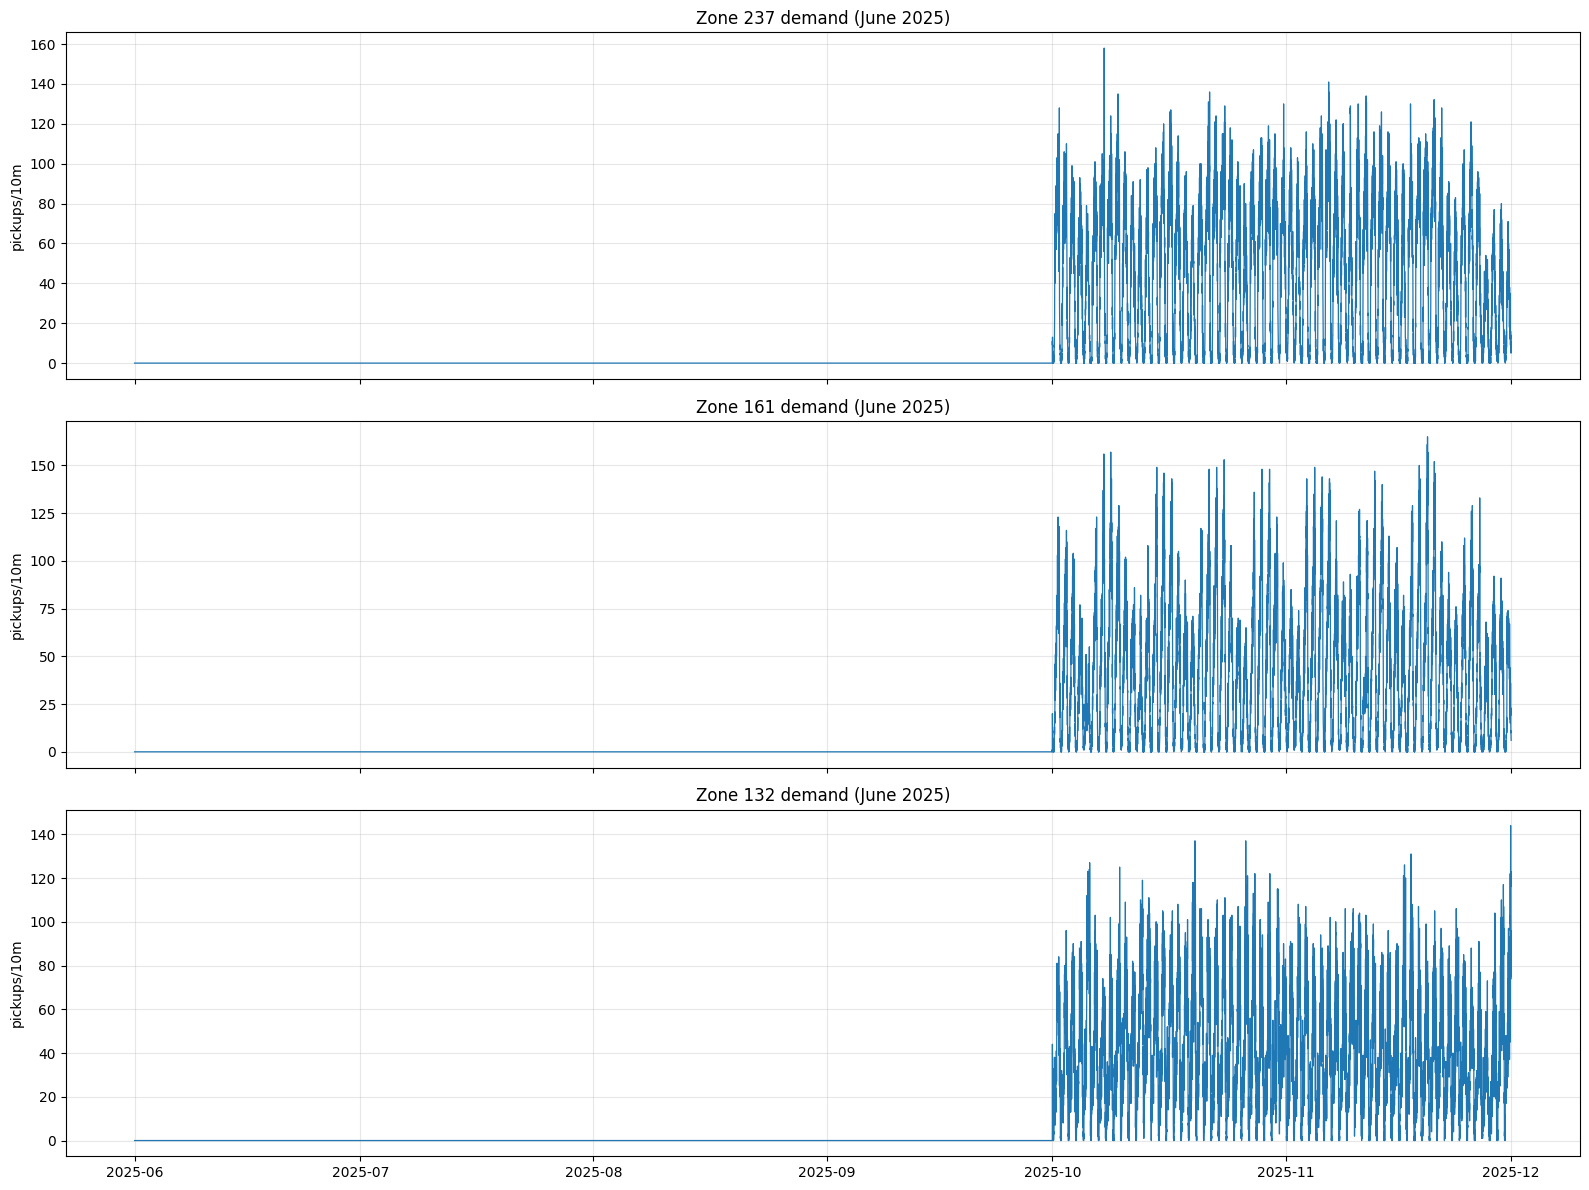

In [9]:
zone_rank = (
    dense_df.groupBy(ZONE_COL).agg(F.sum(TARGET_COL).alias("total"))
    .orderBy(F.col("total").desc())
    .limit(3)
)
top_zones = [r[ZONE_COL] for r in zone_rank.collect()]

max_bin = dense_df.agg(F.max(BIN_COL).alias("max_bin")).first()["max_bin"]
plot_start = pd.Timestamp(max_bin) - pd.Timedelta(days=14)

plot_df = (
    dense_df.where(F.col(ZONE_COL).isin(top_zones))
    .where(F.col(BIN_COL) >= F.to_timestamp(F.lit(str(plot_start))))
    .orderBy(ZONE_COL, BIN_COL)
    .toPandas()
)

preview_csv_path = f"{LOCAL_RESULTS_DIR}/top_zone_14d_preview.csv"
plot_png_path = f"{LOCAL_ARTIFACTS_DIR}/top_zone_14d_plot.png"

if len(plot_df) > 0:
    plot_df.to_csv(preview_csv_path, index=False)

    fig, axes = plt.subplots(len(top_zones), 1, figsize=(16, 4 * len(top_zones)), sharex=True)
    if len(top_zones) == 1:
        axes = [axes]
    for ax, z in zip(axes, top_zones):
        tmp = plot_df[plot_df[ZONE_COL] == z]
        ax.plot(tmp[BIN_COL], tmp[TARGET_COL], linewidth=0.9)
        ax.set_title(f"Zone {z} demand (last 14 days)")
        ax.set_ylabel("pickups/10m")
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(plot_png_path, dpi=130, bbox_inches="tight")
    plt.show()

    print("Saved local preview:", preview_csv_path)
    print("Saved local plot   :", plot_png_path)
else:
    print("No data for plotting.")

In [10]:
# Release Spark cluster resources for subsequent notebooks (e.g., training).
spark.catalog.clearCache()
spark.stop()
print("Feature engineering Spark session stopped.")

Feature engineering Spark session stopped.
